In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("glass.csv")

df.head()

,id,ri,na,mg,al,si,k,ca,ba,fe,type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
df.columns = df.columns.str.strip().str.lower()
print(df['type'].value_counts())

type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [5]:
for col in df.columns:
    print(repr(col))

'id'
'ri'
'na'
'mg'
'al'
'si'
'k'
'ca'
'ba'
'fe'
'type'


In [7]:
df.columns = df.columns.str.strip().str.lower()

target_col = "type"

X = df.drop(columns=[target_col])
y = df[target_col]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Confusion matrices
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

Decision Tree Confusion Matrix:
 [[14  0  0  0  0  0]
 [ 0 15  0  0  0  0]
 [ 0  0  3  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  0  6]]

Random Forest Confusion Matrix:
 [[14  0  0  0  0  0]
 [ 0 15  0  0  0  0]
 [ 0  0  3  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  0  6]]


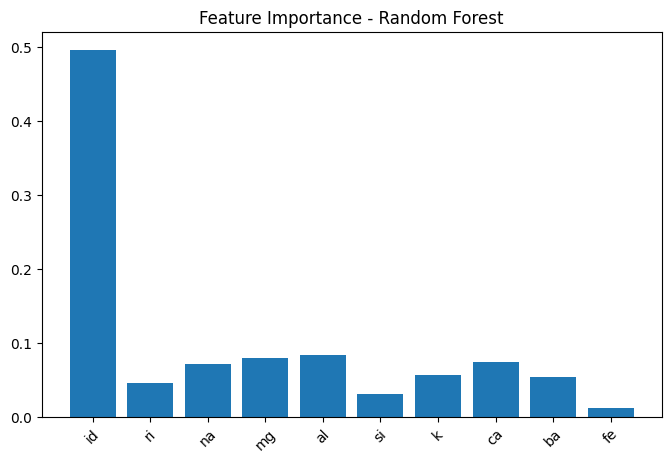

In [14]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importances)
plt.title("Feature Importance - Random Forest")
plt.xticks(rotation=45)
plt.show()